Logistic Regression as Baseline

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    f1_score,
    roc_auc_score,
    roc_curve
)
from sklearn.preprocessing import label_binarize

In [5]:
trainX = pd.read_csv("data/Train/X_train.txt", sep=" ", header=None)
trainY = pd.read_csv("data/Train/y_train.txt", sep=" ", header=None)

testX = pd.read_csv("data/Test/X_test.txt", sep=" ", header=None)
testY = pd.read_csv("data/Test/y_test.txt", sep=" ", header=None)

In [6]:
def validate_data(X, y, name="dataset"):
    print(f"\nChecking {name}...")

    # Check for missing values
    if X.isnull().sum().sum() > 0:
        print("Missing values found!")
    else:
        print("No missing values")

    # label range
    unique_labels = np.unique(y)
    print("Labels:", unique_labels)

    if not set(unique_labels).issubset(set(range(1, 13))):
        raise ValueError("Label out of range!")

validate_data(trainX, trainY, "train")
validate_data(testX, testY, "test")

# reshape label
trainY = trainY.squeeze()
testY = testY.squeeze()


Checking train...
No missing values
Labels: [ 1  2  3  4  5  6  7  8  9 10 11 12]

Checking test...
No missing values
Labels: [ 1  2  3  4  5  6  7  8  9 10 11 12]


In [9]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("feature_select", SelectKBest(score_func=f_classif)),
    ("clf", LogisticRegression(
        solver='saga',
        max_iter=3000,
        class_weight='balanced'
    ))
])

In [10]:
param_grid = {
    "feature_select__k": [100, 200, 300],
    "clf__C": [0.1, 1, 10]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(trainX, trainY)

print("\nBest params:", grid.best_params_)


Best params: {'clf__C': 0.1, 'feature_select__k': 300}


In [21]:
pred = grid.predict(testX)
proba = grid.predict_proba(testX)
print("\nAccuracy:", accuracy_score(testY, pred))
print("F1 (macro):", f1_score(testY, pred, average="macro"))

print("\nClassification Report:")
print(classification_report(testY, pred))


Accuracy: 0.9263124604680582
F1 (macro): 0.8252636924617143

Classification Report:
              precision    recall  f1-score   support

           1       0.96      1.00      0.98       496
           2       0.97      0.94      0.96       471
           3       0.99      0.96      0.98       420
           4       0.92      0.84      0.88       508
           5       0.84      0.94      0.89       556
           6       1.00      0.96      0.98       545
           7       0.61      0.83      0.70        23
           8       0.71      1.00      0.83        10
           9       0.59      0.75      0.66        32
          10       0.75      0.60      0.67        25
          11       0.68      0.57      0.62        49
          12       0.70      0.85      0.77        27

    accuracy                           0.93      3162
   macro avg       0.81      0.85      0.83      3162
weighted avg       0.93      0.93      0.93      3162



<Figure size 1000x800 with 0 Axes>

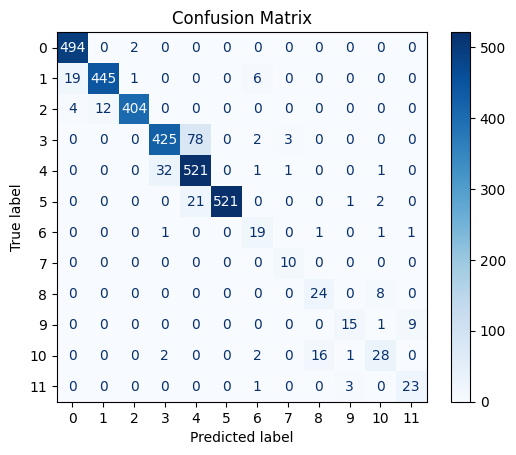

In [17]:
cm = confusion_matrix(testY, pred)

plt.figure(figsize=(10,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

In [22]:
classes = np.unique(testY)

# one-hot
testY_bin = label_binarize(testY, classes=classes)

# One-vs-Rest AUC
auc_ovr = roc_auc_score(testY_bin, proba, multi_class="ovr")
print("\nROC AUC (OvR):", auc_ovr)


ROC AUC (OvR): 0.9948016619494385
